In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models as tv_models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

transform = transforms.Compose([
    transforms.ToTensor(),
])

data_dir = 'dataset'

dataset = datasets.ImageFolder(data_dir, transform=transform)

classes = dataset.classes
print("Классы:", classes)

Классы: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


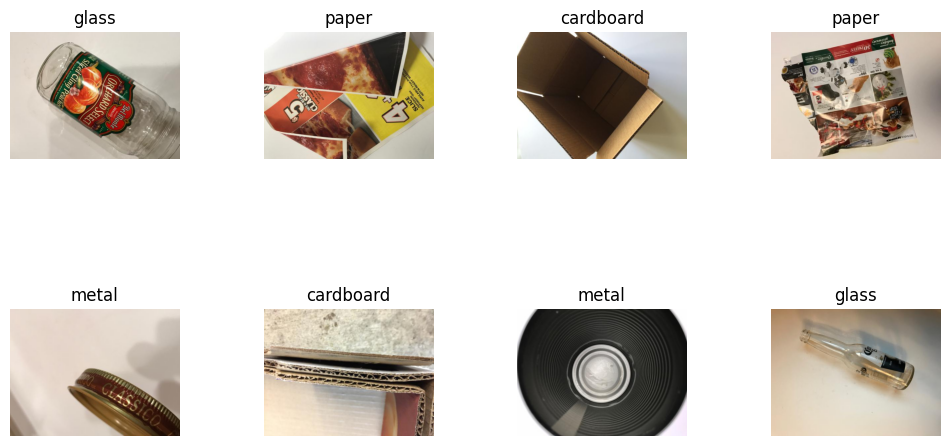

In [2]:
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

data_iter = iter(data_loader)
images, labels = next(data_iter)

class_names = dataset.classes

fig, axes = plt.subplots(figsize=(12, 6), nrows=2, ncols=4)
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for idx, ax in enumerate(axes.flatten()):
    img = images[idx].numpy()
    img = img.transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(class_names[labels[idx]])
    ax.axis('off')

plt.show()

In [ ]:
input_size = 28 * 28 * 3
num_classes = len(dataset.classes)

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_f1, epoch_accuracy

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_f1, epoch_accuracy

num_epochs = 25
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []
train_accuracies, val_accuracies = [], []

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to C:\Users\ESESEY/.cache\torch\hub\checkpoints\mobilenet_v3_large-8738ca79.pth


100.0%


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to C:\Users\ESESEY/.cache\torch\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth


100.0%


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to C:\Users\ESESEY/.cache\torch\hub\checkpoints\squeezenet1_1-b8a52dc0.pth


100.0%


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\ESESEY/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100.0%


Начало обучения: mobilenet_v3_large-feature-extraction
Эпоха 1/25, Обучающие Потери: 1.3620, Обучающий F1: 0.4746, Обучающая Точность: 0.5187, Валидационные Потери: 1.1171, Валидационный F1: 0.5791, Валидационная Точность: 0.6359
Эпоха 2/25, Обучающие Потери: 0.9151, Обучающий F1: 0.6349, Обучающая Точность: 0.6974, Валидационные Потери: 0.8791, Валидационный F1: 0.6659, Валидационная Точность: 0.7098
Эпоха 3/25, Обучающие Потери: 0.7803, Обучающий F1: 0.6916, Обучающая Точность: 0.7268, Валидационные Потери: 0.8177, Валидационный F1: 0.7028, Валидационная Точность: 0.7361
Эпоха 4/25, Обучающие Потери: 0.7194, Обучающий F1: 0.7135, Обучающая Точность: 0.7517, Валидационные Потери: 0.7505, Валидационный F1: 0.7034, Валидационная Точность: 0.7309
Эпоха 5/25, Обучающие Потери: 0.6669, Обучающий F1: 0.7452, Обучающая Точность: 0.7800, Валидационные Потери: 0.6957, Валидационный F1: 0.7207, Валидационная Точность: 0.7652
Эпоха 6/25, Обучающие Потери: 0.6286, Обучающий F1: 0.7685, Обучающая 

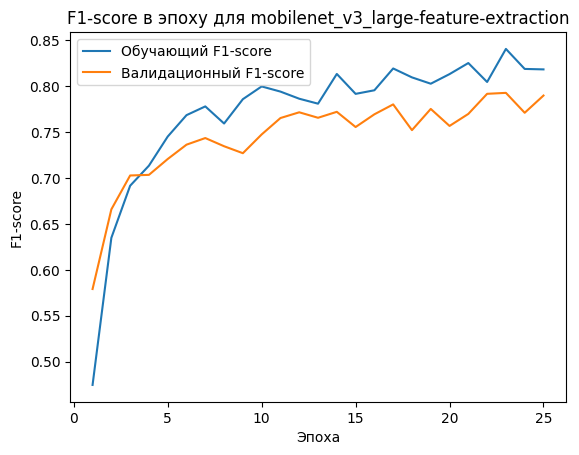

Начало обучения: mobilenet_v3_large-fine-tuning
Эпоха 1/25, Обучающие Потери: 0.9665, Обучающий F1: 0.5796, Обучающая Точность: 0.6324, Валидационные Потери: 0.7917, Валидационный F1: 0.6543, Валидационная Точность: 0.7230
Эпоха 2/25, Обучающие Потери: 0.5230, Обучающий F1: 0.7788, Обучающая Точность: 0.8117, Валидационные Потери: 0.6124, Валидационный F1: 0.7203, Валидационная Точность: 0.7757
Эпоха 3/25, Обучающие Потери: 0.3516, Обучающий F1: 0.8494, Обучающая Точность: 0.8739, Валидационные Потери: 0.4769, Валидационный F1: 0.8172, Валидационная Точность: 0.8364
Эпоха 4/25, Обучающие Потери: 0.2649, Обучающий F1: 0.8860, Обучающая Точность: 0.9021, Валидационные Потери: 0.4337, Валидационный F1: 0.8135, Валидационная Точность: 0.8443
Эпоха 5/25, Обучающие Потери: 0.2165, Обучающий F1: 0.9120, Обучающая Точность: 0.9248, Валидационные Потери: 0.4263, Валидационный F1: 0.8511, Валидационная Точность: 0.8707
Эпоха 6/25, Обучающие Потери: 0.1689, Обучающий F1: 0.9274, Обучающая Точност

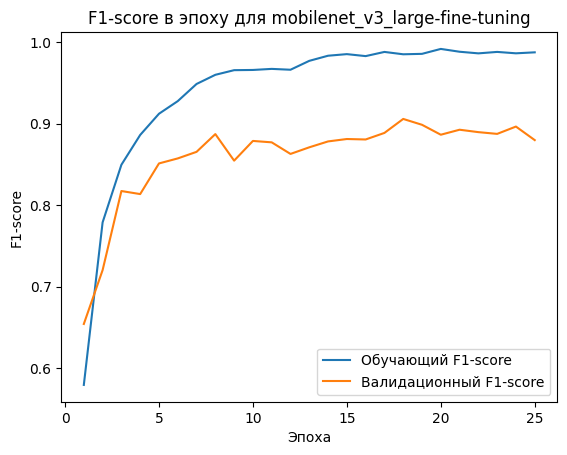

Начало обучения: shufflenet_v2_x1_0-feature-extraction
Эпоха 1/25, Обучающие Потери: 1.7493, Обучающий F1: 0.1279, Обучающая Точность: 0.2528, Валидационные Потери: 1.7040, Валидационный F1: 0.1902, Валидационная Точность: 0.3958
Эпоха 2/25, Обучающие Потери: 1.6828, Обучающий F1: 0.1753, Обучающая Точность: 0.3563, Валидационные Потери: 1.6456, Валидационный F1: 0.2151, Валидационная Точность: 0.3879
Эпоха 3/25, Обучающие Потери: 1.6394, Обучающий F1: 0.2518, Обучающая Точность: 0.4129, Валидационные Потери: 1.6065, Валидационный F1: 0.3140, Валидационная Точность: 0.4512
Эпоха 4/25, Обучающие Потери: 1.6003, Обучающий F1: 0.3755, Обучающая Точность: 0.4949, Валидационные Потери: 1.5684, Валидационный F1: 0.4266, Валидационная Точность: 0.5515
Эпоха 5/25, Обучающие Потери: 1.5634, Обучающий F1: 0.4392, Обучающая Точность: 0.5424, Валидационные Потери: 1.5351, Валидационный F1: 0.4894, Валидационная Точность: 0.5937
Эпоха 6/25, Обучающие Потери: 1.5354, Обучающий F1: 0.4678, Обучающая 

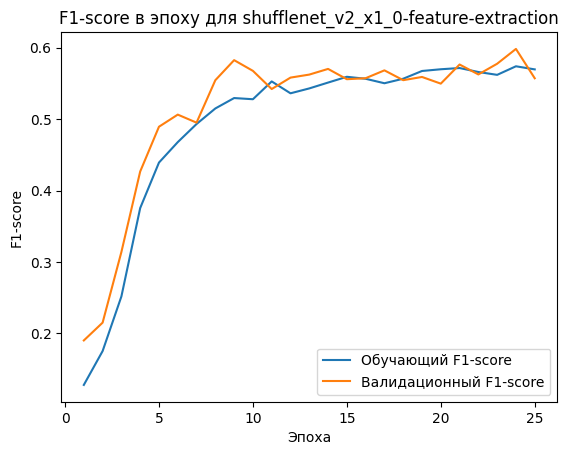

Начало обучения: shufflenet_v2_x1_0-fine-tuning
Эпоха 1/25, Обучающие Потери: 1.7338, Обучающий F1: 0.1649, Обучающая Точность: 0.2981, Валидационные Потери: 1.6474, Валидационный F1: 0.2722, Валидационная Точность: 0.4538
Эпоха 2/25, Обучающие Потери: 1.5508, Обучающий F1: 0.3582, Обучающая Точность: 0.4977, Валидационные Потери: 1.3698, Валидационный F1: 0.5120, Валидационная Точность: 0.6359
Эпоха 3/25, Обучающие Потери: 1.2413, Обучающий F1: 0.5382, Обучающая Точность: 0.6369, Валидационные Потери: 1.0238, Валидационный F1: 0.5956, Валидационная Точность: 0.6992
Эпоха 4/25, Обучающие Потери: 0.9770, Обучающий F1: 0.5812, Обучающая Точность: 0.6816, Валидационные Потери: 0.8419, Валидационный F1: 0.6194, Валидационная Точность: 0.7335
Эпоха 5/25, Обучающие Потери: 0.8300, Обучающий F1: 0.6182, Обучающая Точность: 0.7223, Валидационные Потери: 0.7501, Валидационный F1: 0.6240, Валидационная Точность: 0.7388
Эпоха 6/25, Обучающие Потери: 0.7181, Обучающий F1: 0.6353, Обучающая Точност

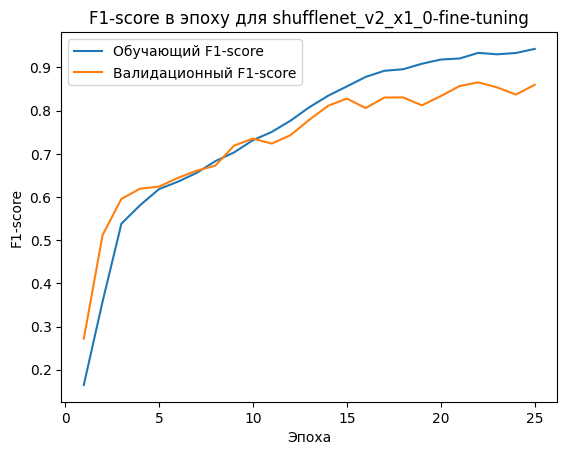

Начало обучения: squeezenet1_1-feature-extraction
Эпоха 1/25, Обучающие Потери: 1.6404, Обучающий F1: 0.3040, Обучающая Точность: 0.3546, Валидационные Потери: 1.2215, Валидационный F1: 0.4832, Валидационная Точность: 0.5778
Эпоха 2/25, Обучающие Потери: 1.1256, Обучающий F1: 0.5155, Обучающая Точность: 0.5967, Валидационные Потери: 0.9569, Валидационный F1: 0.6129, Валидационная Точность: 0.6966
Эпоха 3/25, Обучающие Потери: 0.9237, Обучающий F1: 0.6109, Обучающая Точность: 0.6657, Валидационные Потери: 0.8515, Валидационный F1: 0.6328, Валидационная Точность: 0.6807
Эпоха 4/25, Обучающие Потери: 0.8315, Обучающий F1: 0.6518, Обучающая Точность: 0.6912, Валидационные Потери: 0.8556, Валидационный F1: 0.6634, Валидационная Точность: 0.7124
Эпоха 5/25, Обучающие Потери: 0.8225, Обучающий F1: 0.6670, Обучающая Точность: 0.7014, Валидационные Потери: 0.7695, Валидационный F1: 0.6840, Валидационная Точность: 0.7256
Эпоха 6/25, Обучающие Потери: 0.7137, Обучающий F1: 0.7147, Обучающая Точно

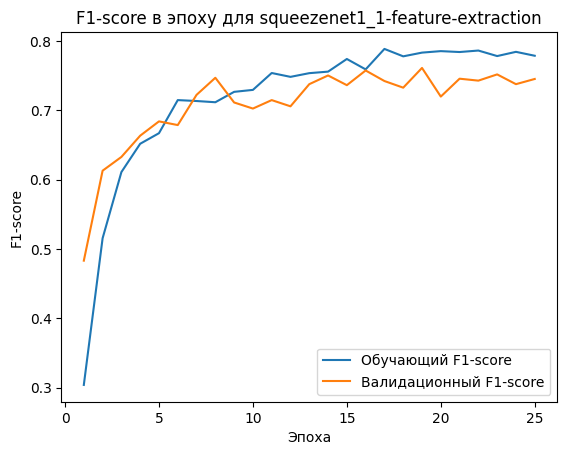

Начало обучения: squeezenet1_1-fine-tuning
Эпоха 1/25, Обучающие Потери: 1.3688, Обучающий F1: 0.3824, Обучающая Точность: 0.4440, Валидационные Потери: 1.0524, Валидационный F1: 0.5137, Валидационная Точность: 0.6042
Эпоха 2/25, Обучающие Потери: 0.9254, Обучающий F1: 0.6024, Обучающая Точность: 0.6680, Валидационные Потери: 0.7902, Валидационный F1: 0.6371, Валидационная Точность: 0.7203
Эпоха 3/25, Обучающие Потери: 0.8074, Обучающий F1: 0.6623, Обучающая Точность: 0.7087, Валидационные Потери: 0.7956, Валидационный F1: 0.6708, Валидационная Точность: 0.7177
Эпоха 4/25, Обучающие Потери: 0.7109, Обучающий F1: 0.7033, Обучающая Точность: 0.7443, Валидационные Потери: 0.6738, Валидационный F1: 0.6968, Валидационная Точность: 0.7467
Эпоха 5/25, Обучающие Потери: 0.6266, Обучающий F1: 0.7303, Обучающая Точность: 0.7664, Валидационные Потери: 0.6268, Валидационный F1: 0.7460, Валидационная Точность: 0.7916
Эпоха 6/25, Обучающие Потери: 0.5610, Обучающий F1: 0.7635, Обучающая Точность: 0.

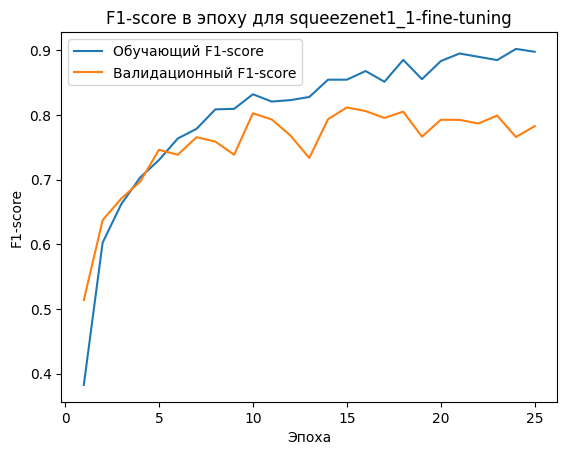

Начало обучения: resnet34-feature-extraction
Эпоха 1/25, Обучающие Потери: 1.6364, Обучающий F1: 0.2702, Обучающая Точность: 0.3162, Валидационные Потери: 1.4216, Валидационный F1: 0.3570, Валидационная Точность: 0.4670
Эпоха 2/25, Обучающие Потери: 1.2667, Обучающий F1: 0.4675, Обучающая Точность: 0.5492, Валидационные Потери: 1.1400, Валидационный F1: 0.5402, Валидационная Точность: 0.6227
Эпоха 3/25, Обучающие Потери: 1.0969, Обучающий F1: 0.5649, Обучающая Точность: 0.6363, Валидационные Потери: 0.9923, Валидационный F1: 0.6178, Валидационная Точность: 0.6755
Эпоха 4/25, Обучающие Потери: 1.0034, Обучающий F1: 0.6008, Обучающая Точность: 0.6589, Валидационные Потери: 0.9622, Валидационный F1: 0.6233, Валидационная Точность: 0.6781
Эпоха 5/25, Обучающие Потери: 0.9346, Обучающий F1: 0.6321, Обучающая Точность: 0.6804, Валидационные Потери: 0.9218, Валидационный F1: 0.6157, Валидационная Точность: 0.6755
Эпоха 6/25, Обучающие Потери: 0.8778, Обучающий F1: 0.6415, Обучающая Точность: 

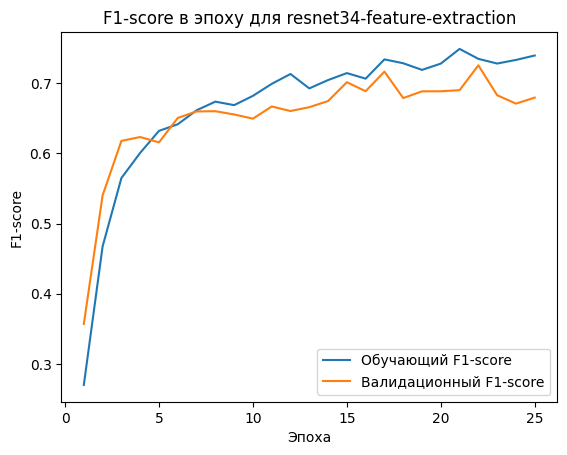

Начало обучения: resnet34-fine-tuning
Эпоха 1/25, Обучающие Потери: 1.0022, Обучающий F1: 0.5729, Обучающая Точность: 0.6301, Валидационные Потери: 0.7861, Валидационный F1: 0.6541, Валидационная Точность: 0.6939
Эпоха 2/25, Обучающие Потери: 0.4863, Обучающий F1: 0.8056, Обучающая Точность: 0.8286, Валидационные Потери: 0.5709, Валидационный F1: 0.7670, Валидационная Точность: 0.8100
Эпоха 3/25, Обучающие Потери: 0.3376, Обучающий F1: 0.8608, Обучающая Точность: 0.8778, Валидационные Потери: 0.4897, Валидационный F1: 0.7929, Валидационная Точность: 0.8179
Эпоха 4/25, Обучающие Потери: 0.2381, Обучающий F1: 0.9031, Обучающая Точность: 0.9169, Валидационные Потери: 0.4298, Валидационный F1: 0.8434, Валидационная Точность: 0.8654
Эпоха 5/25, Обучающие Потери: 0.1918, Обучающий F1: 0.9269, Обучающая Точность: 0.9361, Валидационные Потери: 0.4198, Валидационный F1: 0.8209, Валидационная Точность: 0.8575
Эпоха 6/25, Обучающие Потери: 0.1599, Обучающий F1: 0.9275, Обучающая Точность: 0.9406,

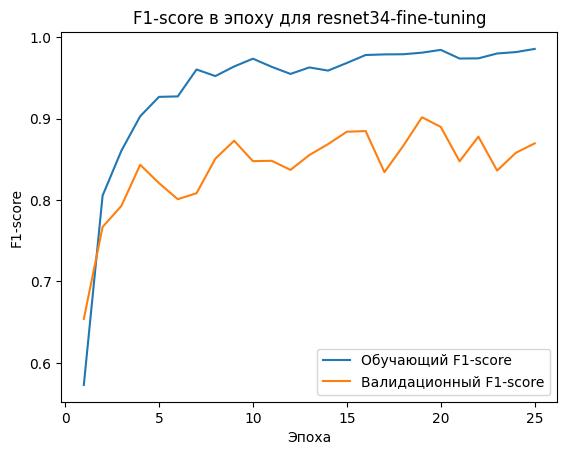

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

data_dir = 'dataset'

dataset = datasets.ImageFolder(data_dir, transform=test_transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_dataset.dataset.transform = train_transform

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

def initialize_transfer_model(model_name, num_classes, feature_extract=True):
    model_ft = None

    if model_name == "mobilenet_v3_large":
        model_ft = tv_models.mobilenet_v3_large(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[3].in_features
        model_ft.classifier[3] = nn.Linear(num_ftrs, num_classes)

    elif model_name == "shufflenet_v2_x1_0":
        model_ft = tv_models.shufflenet_v2_x1_0(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == "squeezenet1_1":
        model_ft = tv_models.squeezenet1_1(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
        model_ft.num_classes = num_classes

    elif model_name == "resnet34":
        model_ft = tv_models.resnet34(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

    return model_ft

def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

num_classes = len(dataset.classes)
model_names = ['mobilenet_v3_large', 'shufflenet_v2_x1_0', 'squeezenet1_1', 'resnet34']
models = []

for model_name in model_names:
    model_ft1 = initialize_transfer_model(model_name, num_classes, feature_extract=True)
    models.append((model_ft1, f'{model_name}-feature-extraction'))

    model_ft2 = initialize_transfer_model(model_name, num_classes, feature_extract=False)
    models.append((model_ft2, f'{model_name}-fine-tuning'))

num_epochs = 25
results = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for model, experiment_name in models:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if experiment_name.endswith('fine-tuning'):
        if experiment_name.startswith('mobilenet_v3_large'):
            base_params = [p for n, p in model.named_parameters() if not n.startswith('classifier')]
            classifier_params = model.classifier.parameters()
        elif experiment_name.startswith('shufflenet_v2_x1_0'):
            base_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]
            classifier_params = model.fc.parameters()
        elif experiment_name.startswith('squeezenet1_1'):
            base_params = [p for n, p in model.named_parameters() if not n.startswith('classifier')]
            classifier_params = model.classifier.parameters()
        elif experiment_name.startswith('resnet34'):
            base_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]
            classifier_params = model.fc.parameters()
        else:
            base_params = model.parameters()
            classifier_params = []
        
        params_to_update = [
            {'params': base_params, 'lr': 0.0001},
            {'params': classifier_params, 'lr': 0.001}
        ]
        optimizer = optim.Adam(params_to_update)
    else:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

    print(f'Начало обучения: {experiment_name}')

    train_losses, val_losses = [], []
    train_f1s, val_f1s = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        train_loss, train_f1, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, val_acc = evaluate_model(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f'Эпоха {epoch+1}/{num_epochs}, '
              f'Обучающие Потери: {train_loss:.4f}, Обучающий F1: {train_f1:.4f}, Обучающая Точность: {train_acc:.4f}, '
              f'Валидационные Потери: {val_loss:.4f}, Валидационный F1: {val_f1:.4f}, Валидационная Точность: {val_acc:.4f}')

    test_loss, test_f1, test_acc = evaluate_model(model, test_loader, criterion, device)
    results.append((experiment_name, test_f1, test_acc))

    print(f'Проверочные Потери: {test_loss:.4f}, Проверочный F1: {test_f1:.4f}, Проверочная Точность: {test_acc:.4f}')

    plt.plot(range(1, num_epochs+1), train_f1s, label='Обучающий F1-score')
    plt.plot(range(1, num_epochs+1), val_f1s, label='Валидационный F1-score')
    plt.xlabel('Эпоха')
    plt.ylabel('F1-score')
    plt.title(f'F1-score в эпоху для {experiment_name}')
    plt.legend()
    plt.show()


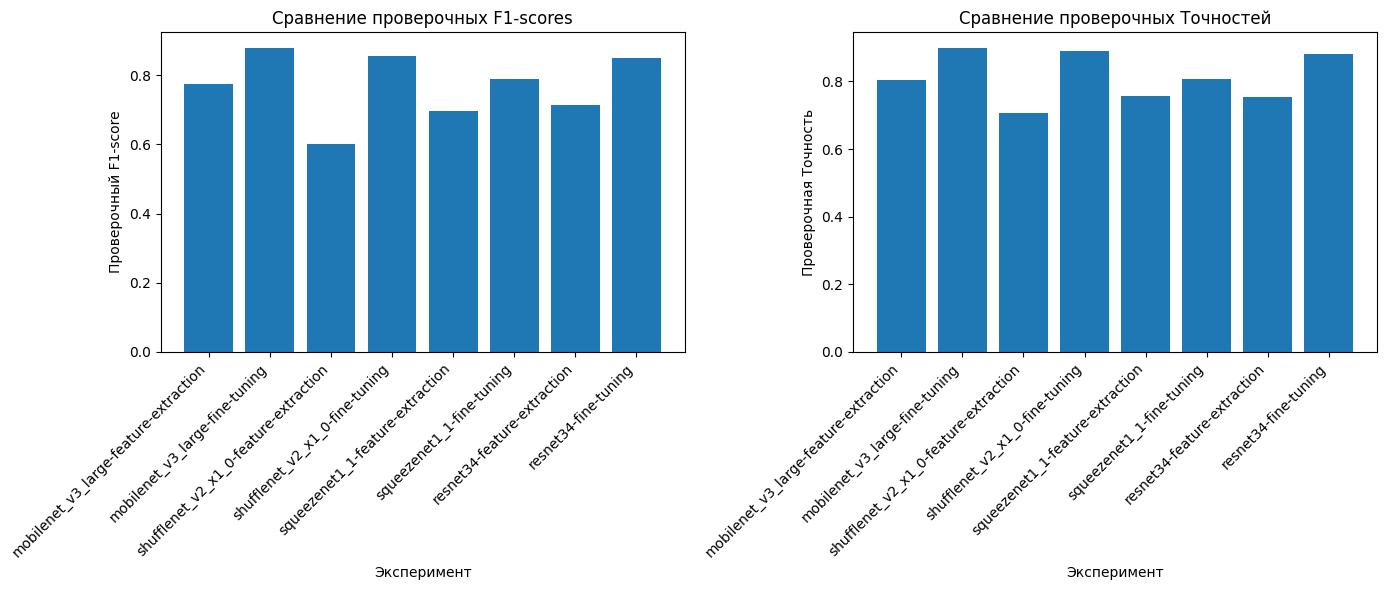

In [7]:
experiment_names, test_f1s, test_accs = zip(*results)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(experiment_names, test_f1s)
plt.xlabel('Эксперимент')
plt.ylabel('Проверочный F1-score')
plt.title('Сравнение проверочных F1-scores')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(experiment_names, test_accs)
plt.xlabel('Эксперимент')
plt.ylabel('Проверочная Точность')
plt.title('Сравнение проверочных Точностей')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()